# 01 - Classification supervisée - ChestMNIST

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import medmnist

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms

## Analyse exploratoire des données

In [70]:
IMG_SIZE = 64
train_dataset = medmnist.ChestMNIST(split="train", download=True, size=IMG_SIZE)
test_dataset = medmnist.ChestMNIST(split="test", download=True, size=IMG_SIZE)

In [71]:
first_data, first_label = train_dataset[0]

type(first_data)

PIL.Image.Image

In [72]:
first_data.size, first_data.mode

((64, 64), 'L')

La données consiste en des images de radiographies de poitrine, de taille 64x64 pixels, en noir et blanc (mode `L` sur `PIL`)

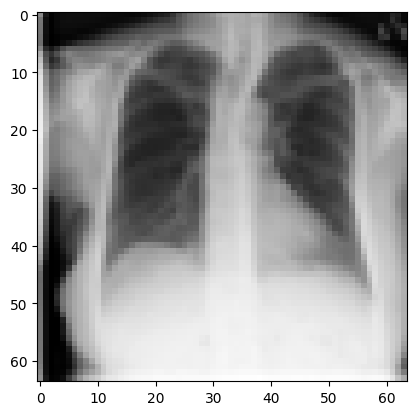

In [73]:
# affichage
plt.imshow(first_data, cmap="gray")
plt.show()

In [74]:
label_names = list(medmnist.INFO["chestmnist"]["label"].values())

print("Pathologies :", ", ".join(label_names))

Pathologies : atelectasis, cardiomegaly, effusion, infiltration, mass, nodule, pneumonia, pneumothorax, consolidation, edema, emphysema, fibrosis, pleural, hernia


In [75]:
labels_df = pd.DataFrame(train_dataset.labels, columns=label_names)

labels_df

,atelectasis,cardiomegaly,effusion,infiltration,mass,nodule,pneumonia,pneumothorax,consolidation,edema,emphysema,fibrosis,pleural,hernia
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78463,0,0,0,0,0,0,0,0,0,0,0,0,0,0
78464,0,0,0,0,0,0,0,0,0,0,0,0,0,0
78465,0,0,0,1,0,1,0,0,0,0,0,0,1,0
78466,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Les labels sont des vecteurs de 14 dimensions. Chaque dimension correspond à une pathologie, et vaut 1 si la pathologie est présente, 0 sinon.

Il s'agit de label et non de classe, car une même image peut présenter plusieurs pathologies.

Nous sommes donc dans un cadre de classification **binaire multi-label**, et non de classification multi-classe.

In [76]:
labels_df["anomalie"] = 0
for label in label_names:
    labels_df["anomalie"] = labels_df["anomalie"] | labels_df[label]

In [77]:
labels_vc = labels_df["anomalie"].value_counts()
labels_vc

anomalie
0    42405
1    36063
Name: count, dtype: int64

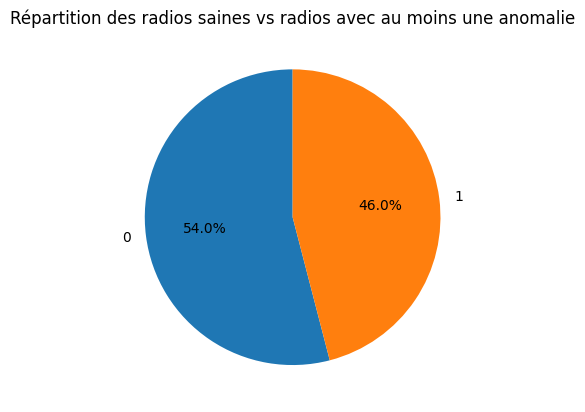

In [78]:
plt.pie(
    labels_vc.values,
    labels=labels_vc.index,
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Répartition des radios saines vs radios avec au moins une anomalie")
plt.show()

Dans le dataset, nous avons 54% de radios saines contre 46% de radios présentant au moins une anomalie.

In [79]:
proportions = labels_df[label_names].mean().sort_values(ascending=False) * 100

proportions

infiltration     17.732069
effusion         11.802263
atelectasis      10.190141
nodule            5.575521
mass              5.082327
pneumothorax      4.721670
consolidation     4.158383
pleural           2.904369
cardiomegaly      2.485089
emphysema         2.292654
edema             2.153744
fibrosis          1.475761
pneumonia         1.246368
hernia            0.183514
dtype: float64

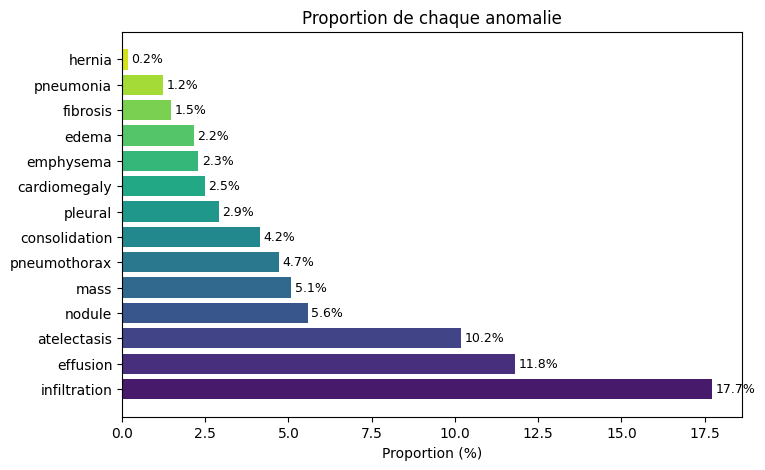

In [80]:
plt.figure(figsize=(8, 5))
colors = sns.color_palette("viridis", len(proportions))
plt.barh(proportions.index, proportions.values, color=colors)
plt.xlabel("Proportion (%)")
plt.title("Proportion de chaque anomalie")
for i, v in enumerate(proportions.values):
    plt.text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=9)
plt.show()

In [81]:
labels_df["nb_anomalie"] = 0
for label in label_names:
    labels_df["nb_anomalie"] = labels_df["nb_anomalie"] + labels_df[label]

In [82]:
labels_df["nb_anomalie"].value_counts().sort_index()

nb_anomalie
0    42405
1    21602
2     9970
3     3378
4      829
5      218
6       49
7       14
8        1
9        2
Name: count, dtype: int64

In [83]:
(labels_df["nb_anomalie"].value_counts() / len(labels_df) * 100).sort_index()

nb_anomalie
0    54.041138
1    27.529694
2    12.705816
3     4.304940
4     1.056482
5     0.277820
6     0.062446
7     0.017842
8     0.001274
9     0.002549
Name: count, dtype: float64

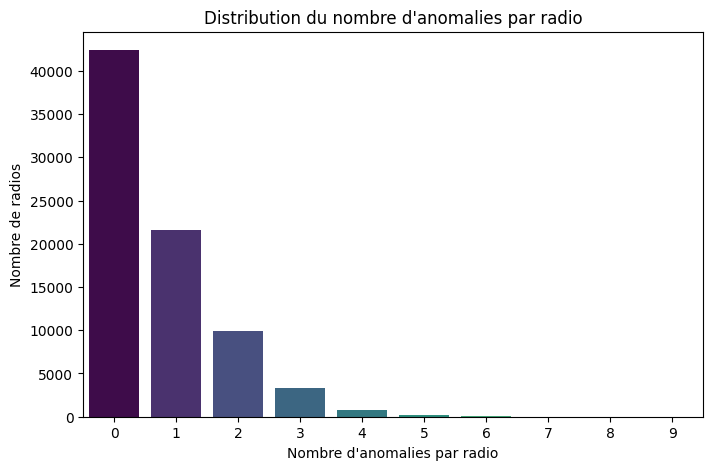

In [84]:
plt.figure(figsize=(8, 5))
sns.countplot(x="nb_anomalie", data=labels_df, palette="viridis", hue="nb_anomalie", legend=False)
plt.xlabel("Nombre d'anomalies par radio")
plt.ylabel("Nombre de radios")
plt.title("Distribution du nombre d'anomalies par radio")
plt.xticks(range(labels_df["nb_anomalie"].max() + 1))
plt.show()

Concernant la distribution du nombre d'anomalies par radio, la majorité des radios présentent 0 ou 1 anomalie, tandis que les radios présentant 2 ou plus anomalies sont moins fréquentes :
- environ 54% des radios présentent 0 anomalie
- environ 27% des radios présentent 1 anomalie
- environ 12% des radios présentent 2 anomalies
- environ 4.3% des radios présentent 3 anomalies

A partir de 4 anomalies, la proportion de radios est très faible (1% ou moins).

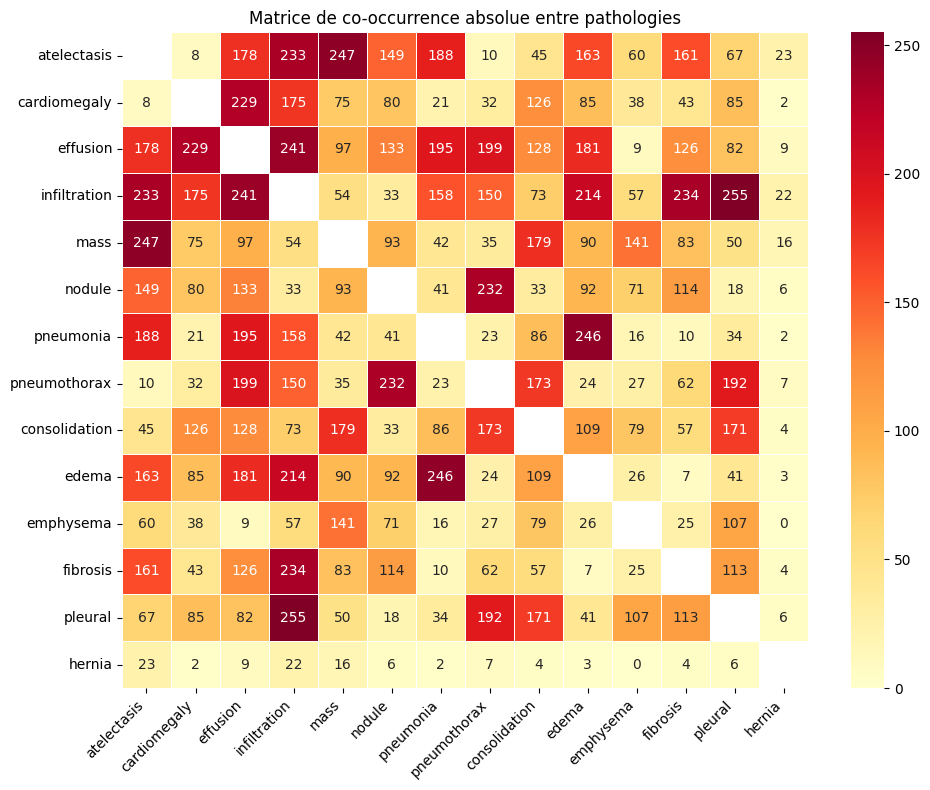

In [85]:
data_labels = labels_df[label_names].values
co_occ = data_labels.T @ data_labels
co_occ_df = pd.DataFrame(co_occ, index=label_names, columns=label_names)

mask = np.eye(len(label_names), dtype=bool)
plt.figure(figsize=(10, 8))
sns.heatmap(
    co_occ_df,
    mask=mask,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    xticklabels=label_names,
    yticklabels=label_names,
)
plt.title("Matrice de co-occurrence absolue entre pathologies")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Nous avons certaines associations d'anomalies qui ressortent visuellement d'après la matrice de co-occurence.
Par exemple :
- infiltration et pleural
- mass et atelectasis
- pneumonia et edema
- infiltration et effusion

Il semble donc qu'il puisse y avoir un lien de causalité, certaines anomalies ouvrant la voie à l'apparition d'autres anomalies.

### Conclusion EDA

Le dataset ChestMNIST est un dataset de **78 468 radiographies thoraciques** annotées avec 14 pathologies en classification **binaire multi-label**.

- 54% des images sont des radios saines, 46% présentent au moins une anomalie. Le dataset est **relativement équilibré** sur cet axe.
- Les pathologies sont très **inégalement réparties** : *Infiltration* et *Effusion* sont les plus fréquentes (~18%), tandis que *Hernia* ou *Pneumonia* sont très rares (<1%). Il y a donc un fort déséquilibre entre les labels.
- Il s'agit d'un problème **multi-label** : une même image peut présenter plusieurs pathologies simultanément.
- Il y a une grande majorité de radios présentant 0 ou 1 anomalie, une faible quantité de radios présentant 2 ou 3 anomalies, et très peu de radios présentant 4 anomalies ou plus.
- Il peut y avoir des associations d'anomalies qui ressortent (co-occurence).

Il faudra donc veiller à utiliser des métriques adaptées au multi-label et à gérer le déséquilibre entre les labels lors de l'entraînement du modèle.

## Entraînement d'un modèle de classification supervisée

In [86]:
# réseau basique : 2 couches de convolutions
class CNN_ChestMNIST_basique(nn.Module):
    def __init__(self, img_size=IMG_SIZE, num_labels=14):
        super(CNN_ChestMNIST_basique, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        final = img_size // 4
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * final * final, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_labels),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# réseau avancé : 3 couchous de convolution, couche cachée du classifier plus grande.

# class CNN_ChestMNIST_avance(nn.Module):
#     def __init__(self, img_size=IMG_SIZE, num_labels=14):
#         super(CNN_ChestMNIST_avance, self).__init__()
#         self.features = nn.Sequential(
#             nn.Conv2d(1, 32, 3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.MaxPool2d(2),
#             nn.Conv2d(32, 64, 3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.MaxPool2d(2),
#             nn.Conv2d(64, 128, 3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.MaxPool2d(2),
#         )
#         final = img_size // 8
#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(128 * final * final, 512),
#             nn.ReLU(),
#             nn.Dropout(0.5),
#             nn.Linear(512, num_labels),
#         )

#     def forward(self, x):
#         return self.classifier(self.features(x))

In [87]:
# hyperparamètres d'entrainement

BATCH_SIZE  = 64
LR          = 1e-3
NUM_EPOCHS  = 10

# on va entrainer sur GPU

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {DEVICE}")

Device : cuda


### Preprocessing des données

Nous allons appliquer les transformations suivantes aux images :
- transformation des images en tenseurs de floats entre 0 et 1 (en divisant les pixels par 255)
- normalisation des images avec une moyenne de 0.5 et un écart-type de 0.5

In [88]:
# Calcul des stats réelles de ChestMNIST
imgs = torch.stack([transforms.ToTensor()(img) for img, _ in train_dataset])
mean = imgs.mean()  # ≈ 0.4976
std  = imgs.std()   # ≈ 0.2479

mean, std

(tensor(0.4979), tensor(0.2450))

In [89]:
# on applique les transformations : tenseur + normalisation
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std), # normalisation
    ] 
)

# Rechargement avec transforms
train_dataset_t = medmnist.ChestMNIST(
    split="train", download=True, size=IMG_SIZE, transform=transform
)
test_dataset_t = medmnist.ChestMNIST(
    split="test", download=True, size=IMG_SIZE, transform=transform
)

In [90]:
# data loaders et gestion du batch

train_loader = DataLoader(train_dataset_t, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset_t,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# test récupération du premier batch
imgs, labels = next(iter(train_loader))
imgs.shape, labels.shape

(torch.Size([64, 1, 64, 64]), torch.Size([64, 14]))

### Entraînement du modèle

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """Entraîne le modèle sur une epoch. Retourne (loss, accuracy) moyens."""
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_elements = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = (
            torch.sigmoid(logits) >= 0.5
        ).float()  # on met le seuil du sigmoid à 0.5 pour la classification binaire
        total_correct += (preds == labels).sum().item()
        total_elements += labels.numel()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = total_correct / total_elements
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    """Evalue le modèle sans mise à jour des poids. Retourne (loss, accuracy) moyens."""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_elements = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)

            # pour le calcul accuracy : sigmoid + seuil à O.5
            preds = (torch.sigmoid(logits) >= 0.5).float() # shape (batch_size, num_labels)
            total_correct += (preds == labels).sum().item() # on somme tous les 0 ou 1 -> entre 0 et (batch * 14)
            total_elements += labels.numel() # batch_size * 14

    avg_loss = total_loss / len(loader.dataset)
    accuracy = total_correct / total_elements
    return avg_loss, accuracy

In [92]:
def train(model, train_loader, test_loader, optimizer, criterion, num_epochs, device):
    """Boucle d'entraînement complète. Retourne l'historique des métriques."""
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        test_loss,  test_acc  = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch:>3}/{num_epochs} | "
            f"Train  loss={train_loss:.4f}  acc={train_acc:.4f} | "
            f"Test   loss={test_loss:.4f}  acc={test_acc:.4f}"
        )

    return history

In [93]:
# Entraînement du modèèle

model_basique = CNN_ChestMNIST_basique().to(DEVICE)
criterion = nn.BCEWithLogitsLoss() # fonction de loss : binary cross entropy, depuis les logits

optimizer_basique = torch.optim.Adam(model_basique.parameters(), lr=LR)

history_basique = train(model_basique, train_loader, test_loader,
                        optimizer_basique, criterion, NUM_EPOCHS, DEVICE)

Epoch   1/10 | Train  loss=0.1816  acc=0.9480 | Test   loss=0.1801  acc=0.9474
Epoch   2/10 | Train  loss=0.1750  acc=0.9486 | Test   loss=0.1736  acc=0.9474
Epoch   3/10 | Train  loss=0.1723  acc=0.9486 | Test   loss=0.1722  acc=0.9474
Epoch   4/10 | Train  loss=0.1703  acc=0.9486 | Test   loss=0.1704  acc=0.9475
Epoch   5/10 | Train  loss=0.1679  acc=0.9487 | Test   loss=0.1710  acc=0.9475
Epoch   6/10 | Train  loss=0.1659  acc=0.9487 | Test   loss=0.1691  acc=0.9477
Epoch   7/10 | Train  loss=0.1641  acc=0.9488 | Test   loss=0.1686  acc=0.9475
Epoch   8/10 | Train  loss=0.1621  acc=0.9489 | Test   loss=0.1682  acc=0.9476
Epoch   9/10 | Train  loss=0.1600  acc=0.9490 | Test   loss=0.1705  acc=0.9476
Epoch  10/10 | Train  loss=0.1582  acc=0.9491 | Test   loss=0.1700  acc=0.9476


### Résultats

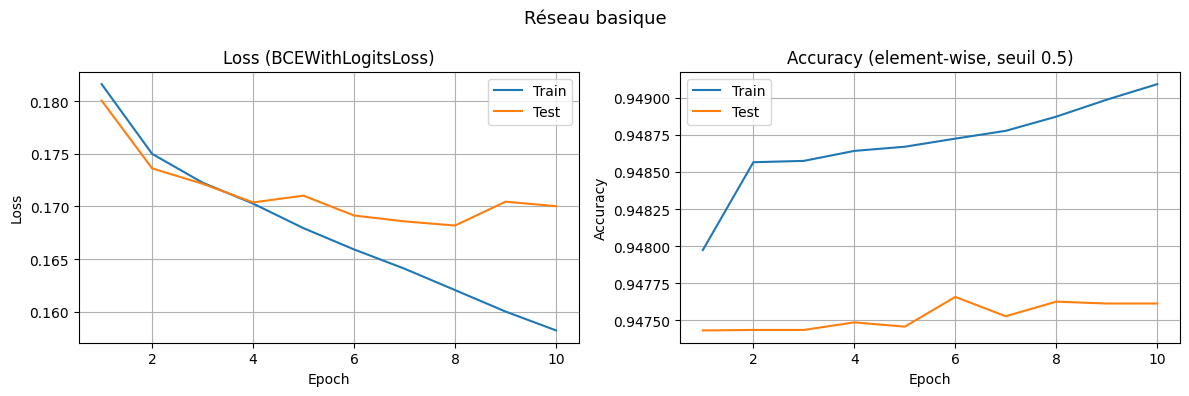

In [94]:
def plot_history(history, title=""):
    """Affiche les courbes de loss et d'accuracy train / test."""
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))
    if title:
        fig.suptitle(title, fontsize=13)

    # --- Loss ---
    ax_loss.plot(epochs, history["train_loss"], label="Train")
    ax_loss.plot(epochs, history["test_loss"],  label="Test")
    ax_loss.set_title("Loss (BCEWithLogitsLoss)")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()
    ax_loss.grid(True)

    # --- Accuracy ---
    ax_acc.plot(epochs, history["train_acc"], label="Train")
    ax_acc.plot(epochs, history["test_acc"],  label="Test")
    ax_acc.set_title("Accuracy (element-wise, seuil 0.5)")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()
    ax_acc.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_basique, title="Réseau basique")


In [99]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import warnings

def logits_to_prediction(model, loader, device):
    """"permet de faire les prédictions à partir des logits"""
    model.eval()
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            all_logits.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(labels.numpy())

    probs  = np.concatenate(all_logits, axis=0)   # (N, 14)  probabilités ∈ [0, 1]
    labels = np.concatenate(all_labels, axis=0)   # (N, 14)  0 ou 1
    preds  = (probs >= 0.5).astype(float)          # (N, 14)  seuil 0.5
    return probs, preds, labels


def calculer_metrics(probs, preds, labels, label_names):
    """Calcule AUC-ROC, F1, Precision, Recall par label + moyennes macro."""
    rows = []
    for i, name in enumerate(label_names):
        y_true = labels[:, i]
        y_prob = probs[:, i]
        y_pred = preds[:, i]

        # AUC ignoré si un seul label présent (ex: Hernia très rare)
        # with warnings.catch_warnings():
        #     warnings.simplefilter("ignore")
        try:
            auc = roc_auc_score(y_true, y_prob)
        except ValueError:
            auc = float("nan")

        rows.append({
            "label":     name,
            "AUC-ROC":   auc,
            "F1":        f1_score(y_true, y_pred, zero_division=0),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall":    recall_score(y_true, y_pred, zero_division=0),
            "Support":   int(y_true.sum()),
        })

    df = pd.DataFrame(rows).set_index("label")

    # ligne macro (moyenne sur les labels)
    df.loc["** Macro **"] = {
        "AUC-ROC":   df["AUC-ROC"].mean(),
        "F1":        df["F1"].mean(),
        "Precision": df["Precision"].mean(),
        "Recall":    df["Recall"].mean(),
        "Support":   df["Support"].sum(),
    }
    return df


def plot_metrics(metrics_df, title=""):
    """Barplot des métriques par label (hors ligne macro)."""
    df = metrics_df.drop("** Macro **").sort_values("AUC-ROC", ascending=True)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    if title:
        fig.suptitle(title, fontsize=13)

    for ax, col, color in zip(axes, ["AUC-ROC", "F1", "Recall"], ["steelblue", "seagreen", "tomato"]):
        ax.barh(df.index, df[col], color=color)
        ax.set_xlim(0, 1)
        ax.set_title(col)
        ax.axvline(df[col].mean(), linestyle="--", color="black", linewidth=1, label=f"macro={df[col].mean():.3f}")
        ax.legend(fontsize=8)
        ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()


In [100]:
probs, preds, labels_test = logits_to_prediction(model_basique, test_loader, DEVICE)

metrics_basique = calculer_metrics(probs, preds, labels_test, label_names)
metrics_basique.style.format("{:.3f}", subset=["AUC-ROC", "F1", "Precision", "Recall"]).background_gradient(
    cmap="RdYlGn", subset=["AUC-ROC", "F1"], vmin=0, vmax=1
)


,AUC-ROC,F1,Precision,Recall,Support
label,,,,,
atelectasis,0.729,0.000,0.000,0.000,2420
cardiomegaly,0.814,0.043,0.650,0.022,582
effusion,0.817,0.107,0.596,0.059,2754
infiltration,0.667,0.022,0.517,0.011,3938
mass,0.687,0.000,0.000,0.000,1133
nodule,0.622,0.000,0.000,0.000,1335
pneumonia,0.667,0.000,0.000,0.000,242
pneumothorax,0.767,0.000,0.000,0.000,1089
consolidation,0.758,0.000,0.000,0.000,957


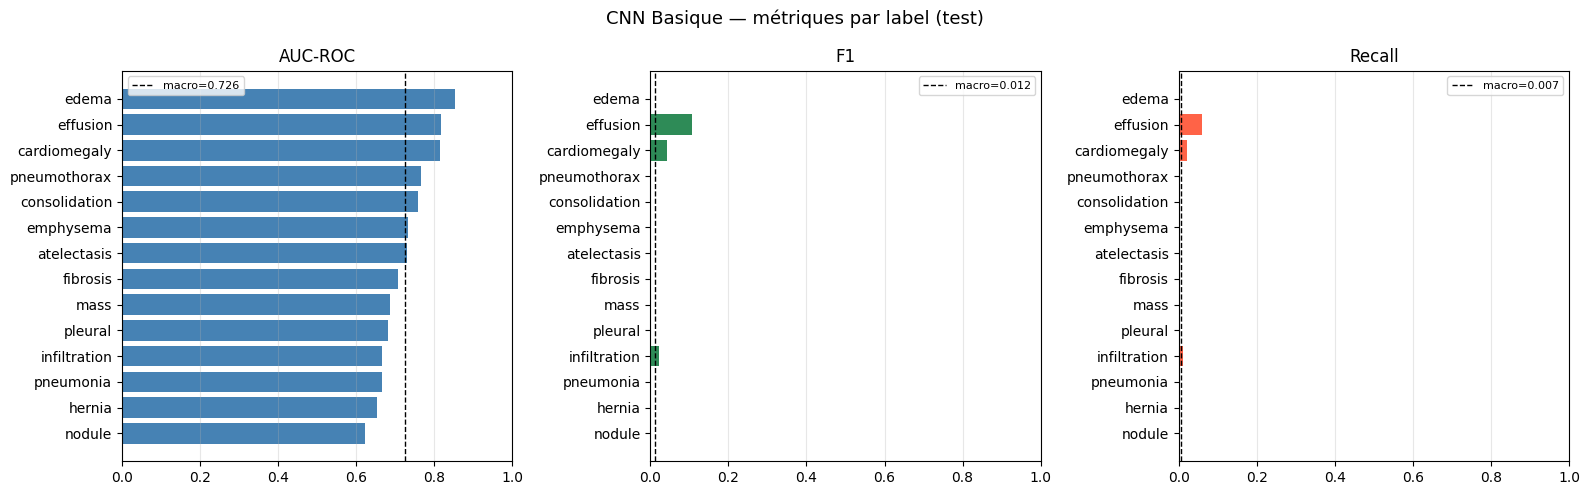

In [101]:
plot_metrics(metrics_basique, title="CNN Basique — métriques par label (test)")
